## Time to get your hands dirty. The HR diagram

This assignment is about stars...

We will work with a star catalogue of 240 stars described by the following information:

- Temperature (in Kelvin)
- Luminosity (L/Lo)
- Radius (R/Ro)
- Absolute magnitude (Mv)

We also have the following data for each star:

- Color (Red/Orange/Yellow/White/Blue)
- Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
- Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

This dataset has been collected by [Deepraj Baidya](https://github.com/deepraj1729) and was originally published on [Kaggle](https://www.kaggle.com/deepu1109/star-dataset). 

In [1]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x1045fb490>)

In [2]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [3]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels_type = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


We've seen this already last time. It is often grood practice to start with a statistical analysis of the dataset to answer the following questions:
* are there any missing values?
* are there NaNs in the data?

In [5]:
import numpy as np
import matplotlib.pyplot as plt

labels = df_stars.columns.to_numpy()
labels

array(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color',
       'Spectral Class'], dtype=object)

lenght of Temperature (K) is 240
Nans in Temperature (K) = 0
lenght of Luminosity(L/Lo) is 240
Nans in Luminosity(L/Lo) = 0
lenght of Radius(R/Ro) is 240
Nans in Radius(R/Ro) = 0
lenght of Absolute magnitude(Mv) is 240
Nans in Absolute magnitude(Mv) = 0
lenght of Star type is 240
Nans in Star type = 0
lenght of Star color is 240
Nans in Star color = 0
lenght of Spectral Class is 240
Nans in Spectral Class = 0


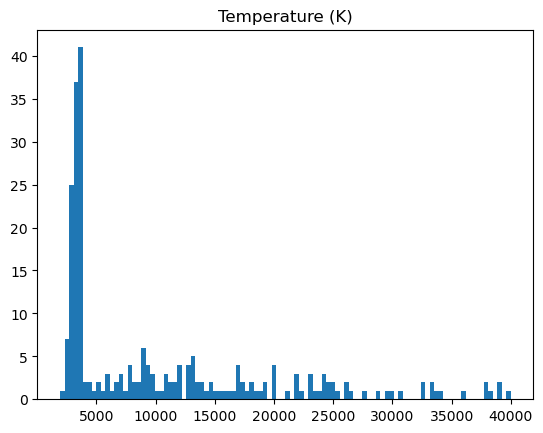

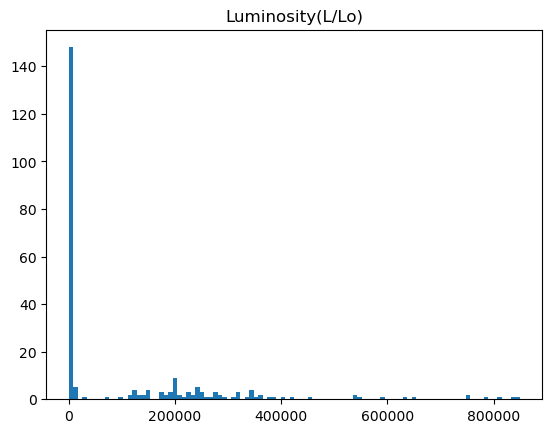

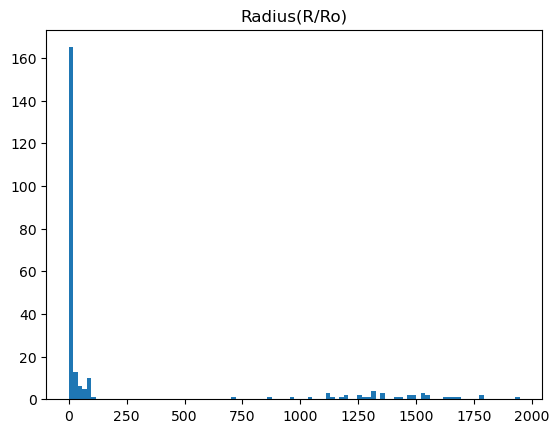

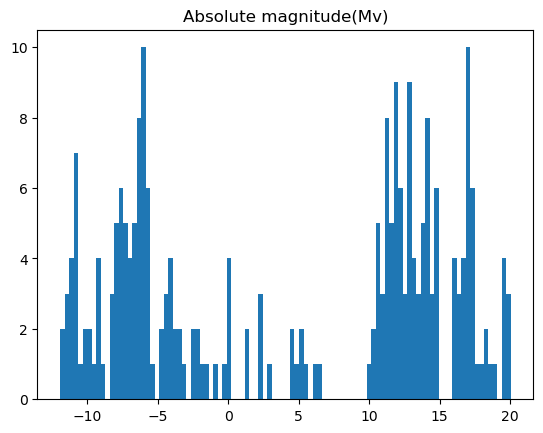

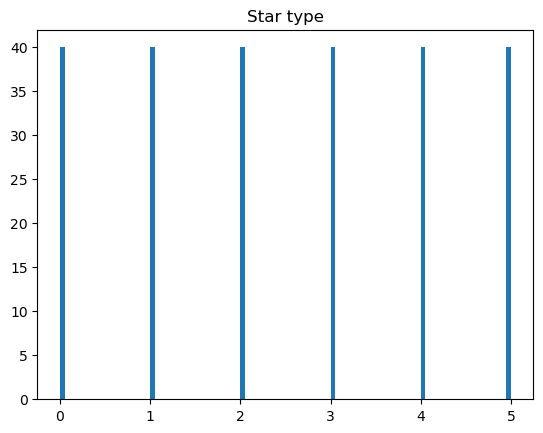

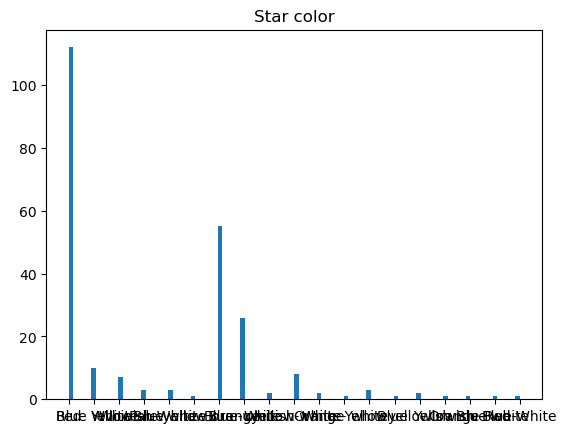

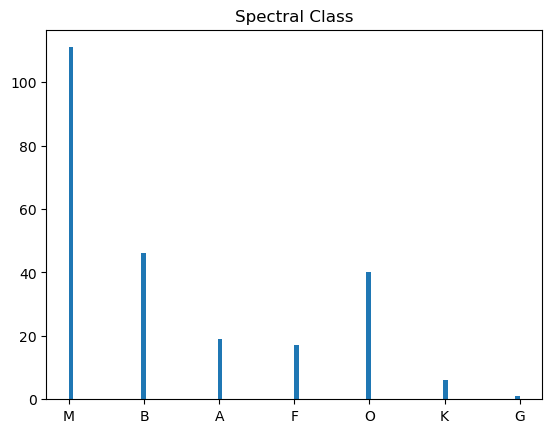

In [6]:
for i in labels:
    plt.figure()
    plt.title(i)
    plt.hist(df_stars[i], bins = 100)
    print('lenght of', i, 'is', len(df_stars[i]))
    print('Nans in', i, '=', len(df_stars[df_stars[i] == 'NaN']))

It seems like there's no missing data! Good!

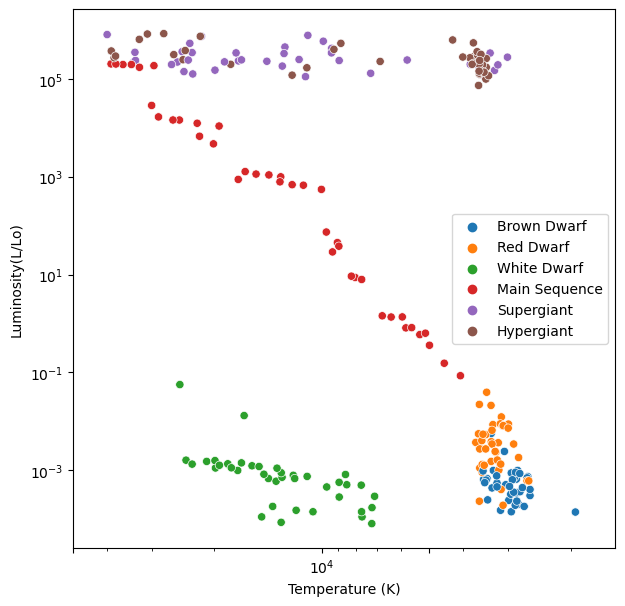

In [7]:
#Plotting the HR diagram!
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels_type)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

- Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
- Project the dataset into the principal components, and do a scatter plot of the first two. 
- This will look terrible. Think about the units!
- Explore what happens if you rescale the data first.

**This is actually a very important lesson in machine learning**: Massaging your data before giving them to an algorithm can make things much much better.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is [the usual machine-learning approach](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) standardize your data such that each dimension has mean=0 and variance=1. 
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?

In [8]:
from sklearn.decomposition import PCA
data = df_stars.drop(columns = ['Star type', 'Star color', 'Spectral Class'])
X = data.to_numpy()

In [9]:
pca = PCA(n_components=4)
pca.fit(X)
new_x = pca.transform(X)

Text(0.5, 1.0, 'PCA results')

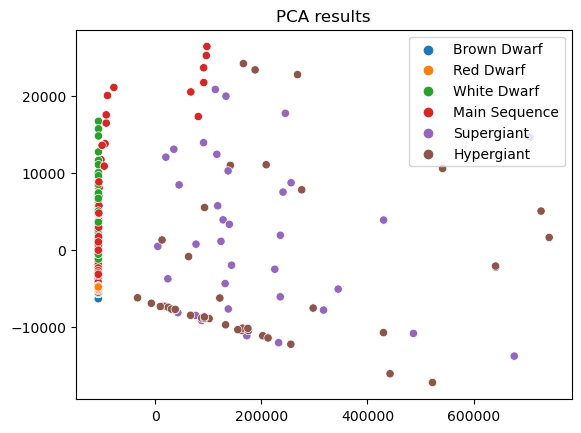

In [10]:
sns.scatterplot(x=new_x[:,0], y=new_x[:,1], hue=labels_type)
plt.title('PCA results')
#plt.xscale('log')
#plt.yscale('log')

Well, this does look terribile ! It does not help us at all. 

Let's rescale the data.

In [11]:
mu = np.mean(X, axis = 0)
sigma = np.std(X, axis = 0)
X_scaled = (X-mu) / sigma
    
re_x = pca.fit_transform(X_scaled) 

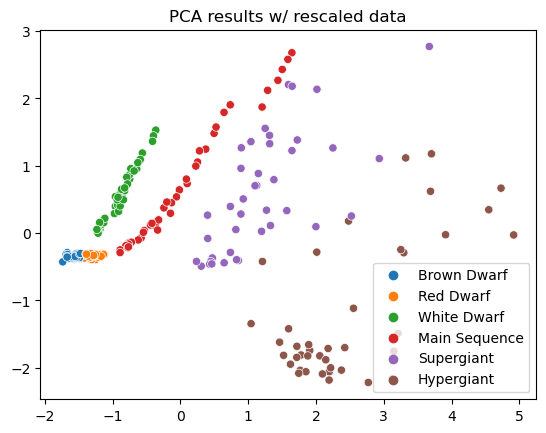

In [12]:
sns.scatterplot(x=re_x[:,0], y=re_x[:,1], hue=labels_type)
plt.title('PCA results w/ rescaled data')
plt.legend(loc = 'lower right')

Now this is much better! 
Let's see if we get the same result using the standardizing Sklearn method.

In [13]:
from sklearn.preprocessing import StandardScaler

stdrd = StandardScaler()
stdrd_X = stdrd.fit_transform(X)
stdrd_pca = pca.fit_transform(stdrd_X)

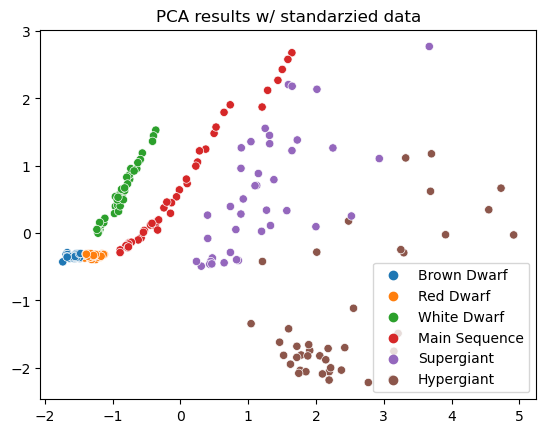

In [14]:
sns.scatterplot(x=stdrd_pca[:,0], y=stdrd_pca[:,1], hue=labels_type)
plt.title('PCA results w/ standarzied data')
plt.legend(loc = 'lower right')

We got the same thing we got 'by hand'! Good!

Let's check how How much variance is explained by the two components we are plotting.

In [15]:
var_ratio = pca.explained_variance_ratio_
tot = var_ratio[0]+var_ratio[1]
print(f'Explained variance: {tot*100:.2f} %')

Explained variance: 83.86 %


Text(0.5, 1.0, 'Scree plot')

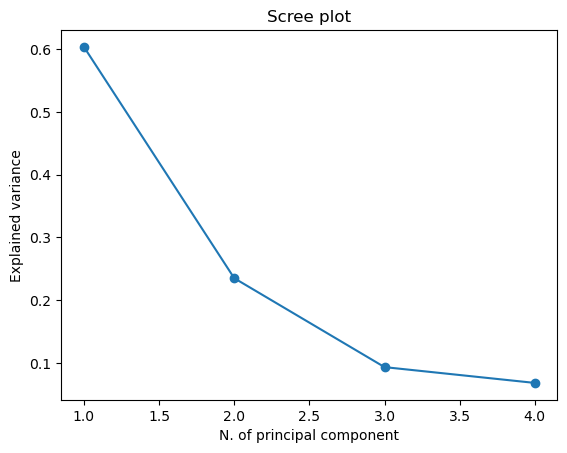

In [23]:
comp = np.array([1,2,3,4])
plt.plot(comp, var_ratio, marker = 'o')
plt.xlabel('N. of principal component')
plt.ylabel('Explained variance')
plt.title('Scree plot')